# Question: Fragment Length Frequency + Rescaling
# Author: G Mahendra Reddy
# Enrollment Number : 23114030

In [1]:
# Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import gzip
from collections import defaultdict

In [2]:
# Streaming fragment length frequency count (no list storage)
length_counts = defaultdict(int)
total_fragments = 0

with open('query.bed', 'rt') as f:
    for line in f:
        parts = line.strip().split()
        try:
            start = int(parts[1])
            end = int(parts[2])
            length = end - start
            if length > 0:
                length_counts[length] += 1
                total_fragments += 1
        except (IndexError, ValueError):
            continue 

In [3]:
# Normalizing frequency
lengths = sorted(length_counts.keys())
normalized_freq = [length_counts[l] / total_fragments for l in lengths]

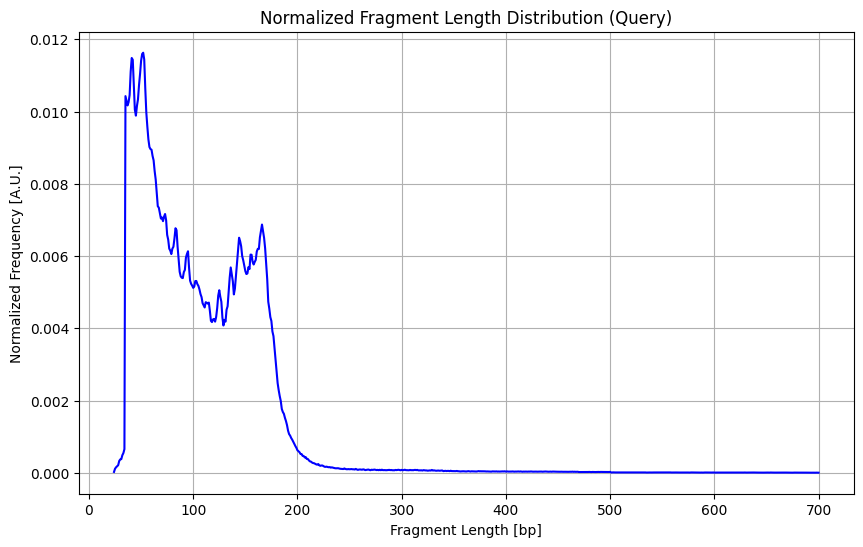

In [4]:
# Plotting normalized fragment length distribution
plt.figure(figsize=(10, 6))
plt.plot(lengths, normalized_freq, color='blue')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Normalized Fragment Length Distribution (Query)')
plt.grid(True)
plt.show()

In [5]:
#  Load reference distribution
reference = pd.read_csv('reference.hist', sep='\t', header=None, names=['length', 'ref_freq'])
reference = reference.dropna()

In [6]:
# Resampling fragment lengths to match reference histogram
# Create reservoir buffers (limited memory) per length during streaming
sample_buffers = defaultdict(list)
max_needed = {}

total_ref = reference['ref_freq'].sum()
for _, row in reference.iterrows():
    l = int(row['length'])
    max_needed[l] = int((row['ref_freq'] / total_ref) * total_fragments)

with open('query.bed', 'rt') as f:
    for line in f:
        parts = line.strip().split()
        try:
            start = int(parts[1])
            end = int(parts[2])
            length = end - start
            if length > 0 and length in max_needed:
                buffer = sample_buffers[length]
                if len(buffer) < max_needed[length]:
                    buffer.append(length)
        except (IndexError, ValueError):
            continue

In [7]:
# Aggregate resampled lengths from all buffers
resampled_counts = {l: len(buffer) for l, buffer in sample_buffers.items()}
total_resampled = sum(resampled_counts.values())
resampled_lengths_sorted = sorted(resampled_counts.keys())
resampled_freq = [resampled_counts[l]/total_resampled for l in resampled_lengths_sorted]

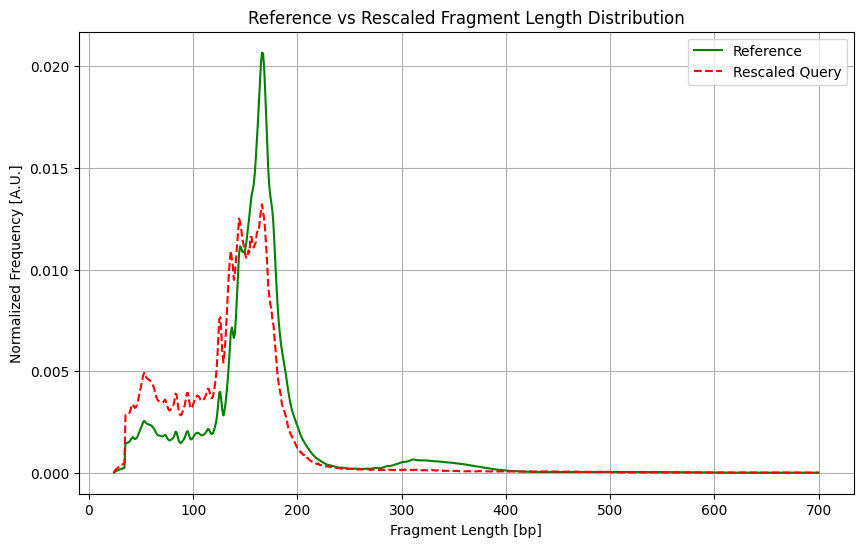

In [8]:
# Plot reference vs rescaled query distribution
plt.figure(figsize=(10, 6))
plt.plot(reference['length'], reference['ref_freq']/reference['ref_freq'].sum(), label='Reference', color='green')
plt.plot(resampled_lengths_sorted, resampled_freq, label='Rescaled Query', color='red', linestyle='--')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Reference vs Rescaled Fragment Length Distribution')
plt.legend()
plt.grid(True)
plt.show()